In [1]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langchain.agents import create_agent
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

# ── import your existing nodes ──────────────────────────
from agents.get_db_schema import get_db_schema_node
from agents.sql_query_generator import sql_query_gen_node
from agents.maths_agent import maths_node
from agents.tavily_search import tavily_search_node

import mysql.connector

load_dotenv()


# ─────────────────────────────────────────────
# STATE DEFINITION
# ─────────────────────────────────────────────
class GraphState(TypedDict):
    user_request: str                                       # original user input
    route: str                                              # "db", "maths" or "search"
    schema: str                                             # filled by get_db_schema_node
    sql_query: str                                          # filled by sql_query_gen_node
    query_result: list                                      # filled by run_query_node
    messages: Annotated[list[BaseMessage], add_messages]    # filled by maths_node / tavily_search_node


# ─────────────────────────────────────────────
# ROUTER NODE — decides db, maths or search
# ─────────────────────────────────────────────
llm_router = ChatGroq(model="openai/gpt-oss-120b", temperature=0)

router_agent = create_agent(
    model=llm_router,
    tools=[],
    system_prompt="""You are a request classifier.
Given a user request, classify it into exactly one of these three categories:

- "db"     : request is about fetching, querying, or retrieving data from a database or students table
- "maths"  : request is about mathematical calculations or operations (add, subtract, multiply, divide, exponents etc.)
- "search" : request is about current events, news, real-time information, or anything that needs web search

Reply with ONLY the single word: db   OR   maths   OR   search
No explanation, no punctuation, nothing else.
"""
)

def router_node(state: dict) -> dict:
    """Classifies user_request into db, maths or search."""
    user_request = state.get("user_request", "")

    response = router_agent.invoke({
        "messages": [{
            "role": "user",
            "content": user_request
        }]
    })

    route = response["messages"][-1].content.strip().lower()

    # Safety fallback — normalize to exact expected values
    if "math" in route:
        route = "maths"
    elif "search" in route:
        route = "search"
    else:
        route = "db"

    print(f"[ROUTER] → routing to: {route}")
    return {"route": route}


# ─────────────────────────────────────────────
# CONDITIONAL EDGE FUNCTION
# ─────────────────────────────────────────────
def route_decision(state: dict) -> str:
    return state.get("route", "db")


# ─────────────────────────────────────────────
# RUN QUERY NODE
# ─────────────────────────────────────────────
def run_query_node(state: dict) -> dict:
    """Executes the generated SQL and returns results."""
    sql_query = state.get("sql_query", "")

    connection = mysql.connector.connect(
        host='localhost',
        user='root',
        password='archit',
        database='porches'
    )
    cursor = connection.cursor(dictionary=True)
    cursor.execute(sql_query)
    result = cursor.fetchall()
    cursor.close()
    connection.close()

    return {"query_result": result}


# ─────────────────────────────────────────────
# GRAPH WIRING
# ─────────────────────────────────────────────
graph = StateGraph(GraphState)

# add all nodes
graph.add_node("router",       router_node)
graph.add_node("get_schema",   get_db_schema_node)
graph.add_node("generate_sql", sql_query_gen_node)
graph.add_node("run_query",    run_query_node)
graph.add_node("maths",        maths_node)
graph.add_node("search",       tavily_search_node)

# entry point always hits router first
graph.set_entry_point("router")

# router decides which branch
graph.add_conditional_edges(
    "router",
    route_decision,
    {
        "db":     "get_schema",
        "maths":  "maths",
        "search": "search"
    }
)

# DB path — sequential
graph.add_edge("get_schema",   "generate_sql")
graph.add_edge("generate_sql", "run_query")
graph.add_edge("run_query",    END)

# Maths and Search paths — straight to END
graph.add_edge("maths",  END)
graph.add_edge("search", END)

app = graph.compile()


# ─────────────────────────────────────────────
# TEST RUNS
# ─────────────────────────────────────────────
if __name__ == "__main__":
    app
    """
    print("\n" + "="*50)
    print("TEST 1: DB query")
    print("="*50)
    result = app.invoke({
        "user_request": "Get all students with cgpa greater than 8"
    })
    print("SQL:", result["sql_query"])
    print("Results:", result["query_result"])

    print("\n" + "="*50)
    print("TEST 2: Maths query")
    print("="*50)
    result = app.invoke({
        "user_request": "What is 25 multiplied by 4 then subtract 10?"
    })
    print("Answer:", result["messages"][-1].content)

    print("\n" + "="*50)
    print("TEST 3: Search query")
    print("="*50)
    result = app.invoke({
        "user_request": "What are today's Indian stock market news headlines?"
    })
    print("Answer:", result["messages"][-1].content)
    """

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


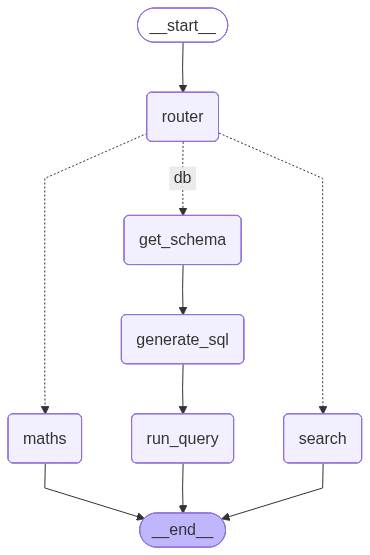

In [2]:
app

In [6]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langchain.agents import create_agent
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

# ── import existing nodes ──────────────────────────
from agents.get_db_schema import get_db_schema_node
from agents.sql_query_generator import sql_query_gen_node
from agents.maths_agent import maths_node
from agents.tavily_search import tavily_search_node
from agents.run_query import run_query_node
from agents.get_weather import get_weather_node

import mysql.connector

load_dotenv()


# ─────────────────────────────────────────────
# STATE DEFINITION
# ─────────────────────────────────────────────
class GraphState(TypedDict):
    user_request: str                                       # original user input
    route: str                                              # "db", "maths" or "search" or "get_weather"
    schema: str                                             # filled by get_db_schema_node
    sql_query: str                                          # filled by sql_query_gen_node
    query_result: list                                      # filled by run_query_node
    messages: Annotated[list[BaseMessage], add_messages]    # filled by maths_node / tavily_search_node / get_weather_node


# ─────────────────────────────────────────────
# ROUTER NODE — decides db, maths or search
# ─────────────────────────────────────────────
llm_router = ChatGroq(model="openai/gpt-oss-120b", temperature=0)

router_agent = create_agent(
    model=llm_router,
    tools=[],
    system_prompt="""You are a request classifier.
Given a user request, classify it into exactly one of these three categories:

- "db"     : request is about fetching, querying, or retrieving data from a database or students table
- "maths"  : request is about mathematical calculations or operations (add, subtract, multiply, divide, exponents etc.)
- "search" : request is about current events, news, real-time information, or anything that needs web search
- "get_weather" : request is about fetching current weather, temperature, or forecast of any city

Reply with ONLY the single word: db   OR   maths   OR   search  OR  get_weather
No explanation, no punctuation, nothing else.
"""
)

def router_node(state: dict) -> dict:
    """Classifies user_request into db, maths, search or get_weather."""
    user_request = state.get("user_request", "")

    response = router_agent.invoke({
        "messages": [{
            "role": "user",
            "content": user_request
        }]
    })

    route = response["messages"][-1].content.strip().lower()
    print(f"[ROUTER RAW OUTPUT] → '{route}'")

    # Safety fallback — normalize to exact expected values
    if "weather" in route:
        route = "get_weather"
    elif "math" in route:
        route = "maths"
    elif "search" in route:
        route = "search"
    else:
        route = "db"

    print(f"[ROUTER] → routing to: {route}")
    return {"route": route}


# ─────────────────────────────────────────────
# CONDITIONAL EDGE FUNCTION
# ─────────────────────────────────────────────
def route_decision(state: dict) -> str:
    return state.get("route", "db")



# ─────────────────────────────────────────────
# GRAPH WIRING
# ─────────────────────────────────────────────
graph = StateGraph(GraphState)

# add all nodes
graph.add_node("router",       router_node)
graph.add_node("get_schema",   get_db_schema_node)
graph.add_node("generate_sql", sql_query_gen_node)
graph.add_node("run_query",    run_query_node)
graph.add_node("maths",        maths_node)
graph.add_node("search",       tavily_search_node)
graph.add_node("get_weather",  get_weather_node)

# entry point always hits router first
graph.set_entry_point("router")

# router decides which branch
graph.add_conditional_edges(
    "router",
    route_decision,
    {
        "db":     "get_schema",
        "maths":  "maths",
        "search": "search",
        "get_weather": "get_weather"
    }
)

# DB path — sequential
graph.add_edge("get_schema",   "generate_sql")
graph.add_edge("generate_sql", "run_query")
graph.add_edge("run_query",    END)
graph.add_edge("get_weather",  END)

# Maths and Search paths — straight to END
graph.add_edge("maths",  END)
graph.add_edge("search", END)

app = graph.compile()



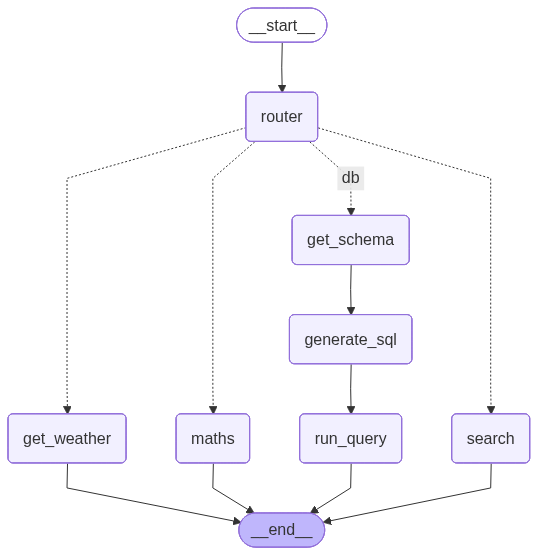

In [7]:
app

In [2]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langchain.agents import create_agent
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

# ── import existing nodes ──────────────────────────
from agents.get_db_schema import get_db_schema_node
from agents.sql_query_generator import sql_query_gen_node
from agents.maths_agent import maths_node
from agents.tavily_search import tavily_search_node
from agents.run_query import run_query_node
from agents.get_weather import get_weather_node
from agents.query_summarize import summarization_node

import mysql.connector

load_dotenv()


# ─────────────────────────────────────────────
# STATE DEFINITION
# ─────────────────────────────────────────────
class GraphState(TypedDict):
    user_request: str                                       # original user input
    route: str                                              # "db", "maths" or "search" or "get_weather"
    schema: str                                             # filled by get_db_schema_node
    sql_query: str                                          # filled by sql_query_gen_node
    query_result: list                                      # filled by run_query_node
    messages: Annotated[list[BaseMessage], add_messages]    # filled by maths_node / tavily_search_node / get_weather_node / summarization_node


# ─────────────────────────────────────────────
# ROUTER NODE — decides db, maths or search
# ─────────────────────────────────────────────
llm_router = ChatGroq(model="openai/gpt-oss-120b", temperature=0)

router_agent = create_agent(
    model=llm_router,
    tools=[],
    system_prompt="""You are a request classifier.
Given a user request, classify it into exactly one of these three categories:

- "db"     : request is about fetching, querying, or retrieving data from a database or students table and summarize the data too
- "maths"  : request is about mathematical calculations or operations (add, subtract, multiply, divide, exponents etc.)
- "search" : request is about current events, news, real-time information, or anything that needs web search
- "get_weather" : request is about fetching current weather, temperature, or forecast of any city

Reply with ONLY the single word: db   OR   maths   OR   search  OR  get_weather
No explanation, no punctuation, nothing else.
"""
)

def router_node(state: dict) -> dict:
    """Classifies user_request into db, maths, search or get_weather."""
    user_request = state.get("user_request", "")

    response = router_agent.invoke({
        "messages": [{
            "role": "user",
            "content": user_request
        }]
    })

    route = response["messages"][-1].content.strip().lower()
    print(f"[ROUTER RAW OUTPUT] → '{route}'")

    # Safety fallback — normalize to exact expected values
    if "weather" in route:
        route = "get_weather"
    elif "math" in route:
        route = "maths"
    elif "search" in route:
        route = "search"
    else:
        route = "db"

    print(f"[ROUTER] → routing to: {route}")
    return {"route": route}


# ─────────────────────────────────────────────
# CONDITIONAL EDGE FUNCTION
# ─────────────────────────────────────────────
def route_decision(state: dict) -> str:
    return state.get("route", "db")



# ─────────────────────────────────────────────
# GRAPH WIRING
# ─────────────────────────────────────────────
graph = StateGraph(GraphState)

# add all nodes
graph.add_node("router",       router_node)
graph.add_node("get_schema",   get_db_schema_node)
graph.add_node("generate_sql", sql_query_gen_node)
graph.add_node("run_query",    run_query_node)
graph.add_node("summarize_query",  summarization_node)
graph.add_node("maths",        maths_node)
graph.add_node("search",       tavily_search_node)
graph.add_node("get_weather",  get_weather_node)

# entry point always hits router first
graph.set_entry_point("router")

# router decides which branch
graph.add_conditional_edges(
    "router",
    route_decision,
    {
        "db":     "get_schema",
        "maths":  "maths",
        "search": "search",
        "get_weather": "get_weather"
    }
)

# DB path — sequential
graph.add_edge("get_schema",   "generate_sql")
graph.add_edge("generate_sql", "run_query")
graph.add_edge("run_query",   "summarize_query")
graph.add_edge("get_weather",  END)

# Maths and Search paths — straight to END
graph.add_edge("maths",  END)
graph.add_edge("search", END)
graph.add_edge("summarize_query", END)

app = graph.compile()


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-120b` in organization `org_01kssdgvbme7sr7ezyaw4a9fk6` service tier `on_demand` on tokens per day (TPD): Limit 200000, Used 198840, Requested 2293. Please try again in 8m9.456s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [1]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langchain.agents import create_agent
from langchain_groq import ChatGroq
from dotenv import load_dotenv

from agents.get_db_schema import get_db_schema_node
from agents.sql_query_generator import sql_query_gen_node
from agents.maths_agent import maths_node
from agents.tavily_search import tavily_search_node
from agents.run_query import run_query_node
from agents.get_weather import get_weather_node
from agents.query_summarize import summarization_node

load_dotenv()



class GraphState(TypedDict):
    user_request: str                                       # original user input
    route: str                                              # "db", "maths", "search", or "get_weather"
    schema: str                                             # filled by get_db_schema_node
    sql_query: str                                          # filled by sql_query_gen_node
    query_result: list                                      # filled by run_query_node
    messages: Annotated[list[BaseMessage], add_messages]    # filled by downstream nodes



_llm_router = ChatGroq(model="openai/gpt-oss-120b", temperature=0)

_router_agent = create_agent(
    model=_llm_router,
    tools=[],
    system_prompt="""You are a request classifier.
Given a user request, classify it into exactly one of these four categories:

- "db"          : request is about fetching, querying, or retrieving data from a database or students table
- "maths"       : request is about mathematical calculations or operations (add, subtract, multiply, divide, exponents, logs, etc.)
- "search"      : request is about current events, news, real-time information, or anything needing a web search
- "get_weather" : request is about fetching current weather, temperature, or forecast for any city

Reply with ONLY the single word: db  OR  maths  OR  search  OR  get_weather
No explanation, no punctuation, nothing else.
""",
)


def router_node(state: dict) -> dict:
    """Classifies user_request into db, maths, search, or get_weather."""
    user_request = state.get("user_request", "")

    response = _router_agent.invoke({
        "messages": [{"role": "user", "content": user_request}]
    })

    raw = response["messages"][-1].content.strip().lower()
    print(f"[ROUTER RAW] → '{raw}'")

    if "weather" in raw:
        route = "get_weather"
    elif "math" in raw:
        route = "maths"
    elif "search" in raw:
        route = "search"
    else:
        route = "db"

    print(f"[ROUTER] → {route}")
    return {"route": route}


def _route_decision(state: dict) -> str:
    return state.get("route", "db")


def build_graph() -> StateGraph:
    graph = StateGraph(GraphState)

    # nodes
    graph.add_node("router",         router_node)
    graph.add_node("get_schema",     get_db_schema_node)
    graph.add_node("generate_sql",   sql_query_gen_node)
    graph.add_node("run_query",      run_query_node)
    graph.add_node("summarize_query", summarization_node)
    graph.add_node("maths",          maths_node)
    graph.add_node("search",         tavily_search_node)
    graph.add_node("get_weather",    get_weather_node)

    # entry point
    graph.set_entry_point("router")

    # conditional routing
    graph.add_conditional_edges(
        "router",
        _route_decision,
        {
            "db":          "get_schema",
            "maths":       "maths",
            "search":      "search",
            "get_weather": "get_weather",
        },
    )

    # DB path — sequential pipeline
    graph.add_edge("get_schema",     "generate_sql")
    graph.add_edge("generate_sql",   "run_query")
    graph.add_edge("run_query",      "summarize_query")
    graph.add_edge("summarize_query", END)

    # direct-to-END paths
    graph.add_edge("maths",       END)
    graph.add_edge("search",      END)
    graph.add_edge("get_weather", END)

    return graph


app = build_graph().compile()

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Here are 5 pendrives up to 128gb available in India:

1. Toshiba U203 128 GB Pen Drive - ₹1,199 - https://www.flipkart.com/toshiba-u203-128-gb-pen-drive/product-reviews/itmf3qyajz4zagvd?pid=ACCERPMH3FRDT2QA
2. SanDisk Ultra Dual Drive Luxe Type-C 128GB - ₹2,499 - https://www.amazon.in/Drives-128-GB-more/s?rh=n%3A1375411031%2Cp_n_size_browse-bin%3A1464339031
3. HP x700w 128 GB Pen Drive - ₹1,799 - https://www.flipkart.com/computers/storage/pen-drives/128-gb~capacity/pr
4. SanDisk Ultra Luxe Type-C 128GB - ₹2,099 - https://www.amazon.in/128gb-pendrive-3-2-high-speed/s?k=128gb+pendrive+3.2+high+speed&page=2
5. EVM EnVault USB 2.0 Flash Drive - ₹1,199 - https://www.flipkart.com/computers/storage/pen-drives/pr

Please note that prices may vary depending on the seller and availability.


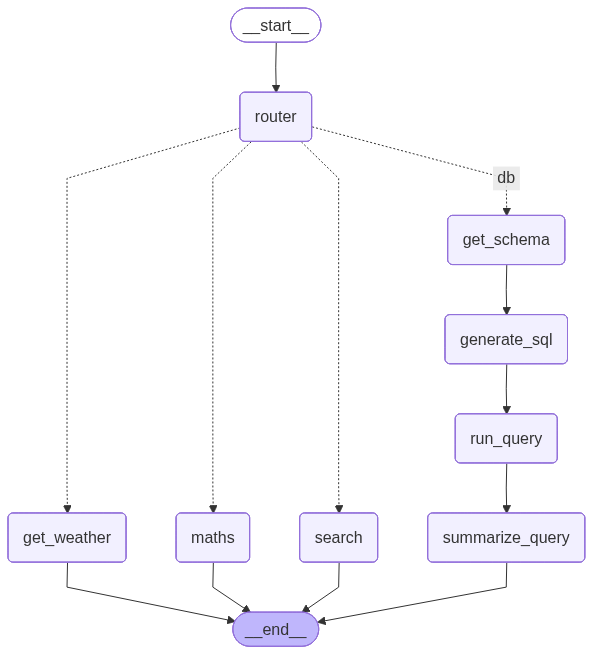

In [2]:
app

In [3]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from dotenv import load_dotenv

from agents.get_db_schema import get_db_schema_node
from agents.sql_query_generator import sql_query_gen_node
from agents.maths_agent import maths_node
from agents.tavily_search import tavily_search_node
from agents.run_query import run_query_node
from agents.get_weather import get_weather_node
from agents.query_summarize import summarization_node
from agents.result_gen import polish_result_node          # ← your new file

load_dotenv()


# ── State ──────────────────────────────────────────────────────────────────────

class GraphState(TypedDict):
    user_request:  str                                        # original user input
    route:         str                                        # "db" | "maths" | "search" | "get_weather"
    schema:        str                                        # filled by get_db_schema_node
    sql_query:     str                                        # filled by sql_query_gen_node
    query_result:  list                                       # filled by run_query_node
    messages:      Annotated[list[BaseMessage], add_messages] # filled by downstream nodes


# ── LLM for Router ─────────────────────────────────────────────────────────────

_llm_router = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

_ROUTER_SYSTEM = """You are a request classifier.
Given a user request, classify it into exactly one of these four categories:

- "db"          : request is about fetching, querying, or retrieving data from a database or students table
- "maths"       : request is about mathematical calculations or operations (add, subtract, multiply, divide, exponents, logs, etc.)
- "search"      : request is about current events, news, real-time information, or anything needing a web search
- "get_weather" : request is about fetching current weather, temperature, or forecast for any city

Reply with ONLY the single word: db  OR  maths  OR  search  OR  get_weather
No explanation, no punctuation, nothing else."""


# ── Router Node ────────────────────────────────────────────────────────────────

def router_node(state: dict) -> dict:
    """Classifies user_request into db, maths, search, or get_weather.
    Single direct LLM call — no agent, no loop."""
    user_request = state.get("user_request", "")

    response = _llm_router.invoke([
        SystemMessage(content=_ROUTER_SYSTEM),
        HumanMessage(content=user_request),
    ])

    raw = response.content.strip().lower()
    print(f"[ROUTER RAW] → '{raw}'")

    if "weather" in raw:
        route = "get_weather"
    elif "math" in raw:
        route = "maths"
    elif "search" in raw:
        route = "search"
    else:
        route = "db"

    print(f"[ROUTER] → {route}")
    return {"route": route}


def _route_decision(state: dict) -> str:
    return state.get("route", "db")


# ── Graph ──────────────────────────────────────────────────────────────────────

def build_graph() -> StateGraph:
    graph = StateGraph(GraphState)

    # ── nodes ──────────────────────────────────────────────────────────────────
    graph.add_node("router",          router_node)
    graph.add_node("get_schema",      get_db_schema_node)
    graph.add_node("generate_sql",    sql_query_gen_node)
    graph.add_node("run_query",       run_query_node)
    graph.add_node("summarize_query", summarization_node)
    graph.add_node("maths",           maths_node)
    graph.add_node("search",          tavily_search_node)
    graph.add_node("get_weather",     get_weather_node)
    graph.add_node("polish_result",   polish_result_node)  # ← imported from result_gen.py

    # ── entry point ────────────────────────────────────────────────────────────
    graph.set_entry_point("router")

    # ── conditional routing ────────────────────────────────────────────────────
    graph.add_conditional_edges(
        "router",
        _route_decision,
        {
            "db":          "get_schema",
            "maths":       "maths",
            "search":      "search",
            "get_weather": "get_weather",
        },
    )

    # ── DB path — sequential pipeline ─────────────────────────────────────────
    graph.add_edge("get_schema",      "generate_sql")
    graph.add_edge("generate_sql",    "run_query")
    graph.add_edge("run_query",       "summarize_query")
    graph.add_edge("summarize_query", "polish_result")

    # ── all paths funnel through polish before END ─────────────────────────────
    graph.add_edge("maths",           "polish_result")
    graph.add_edge("search",          "polish_result")
    graph.add_edge("get_weather",     "polish_result")
    graph.add_edge("polish_result",   END)

    return graph


app = build_graph().compile()

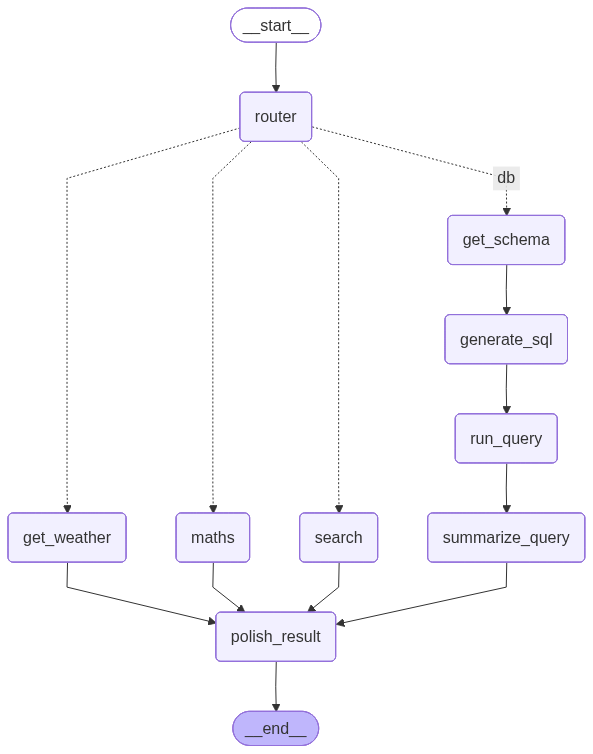

In [4]:
app